# FCVE Training: CFE-Modell + Decoder — MNIST (alle 3 Ziffernpaare)
**Datensatz:** MNIST, alle drei Ziffernpaare (3-8, 4-9, 5-6) werden in **einem** Durchlauf
nacheinander trainiert und ausgewertet.
**Modell:** Custom ResNet-18 (MNIST-Variante, siehe `mnist-resnet18-training.ipynb`)
**Methode:** Faithful Counterfactual Visual Explanations (FCVE) nach Khan et al. (2025)

Der komplette Trainings-/Auswertungs-Code pro Ziffernpaar ist unveraendert -- nur in eine
Funktion `run_fcve_pipeline(pair_key)` verpackt, die fuer jedes der drei Paare einmal
aufgerufen wird. Am Ende werden die Metriken (L1, Sparsity, LPIPS, FID, Validity,
Denoised Validity, Coverage, Efficiency) ueber alle drei Paare **gemittelt** ausgegeben.

### Outputs
- `./fcve_cfe_model_<PAIR_KEY>.pth`, `./fcve_decoder_<PAIR_KEY>.pth` -- pro Paar
- `./metrics_summary.csv` -- alle 3 Paare + eine `MEAN`-Zeile mit dem Durchschnitt


## 1. Imports & globale Konfiguration

In [1]:
import os
import struct
import numpy as np
from array import array
from os.path import join
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Geraet:', DEVICE)

# ── Alle drei Ziffernpaare -- werden unten in einer Schleife nacheinander durchlaufen ──
TASK_PAIRS = {'38': (3, 8), '49': (4, 9), '56': (5, 6)}
METHOD = 'FCVE'

# ── Pfade (MNIST-Rohdaten, IDX-Format, wie auf Kaggle bereitgestellt) ─────────
INPUT_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset'
TRAIN_IMAGES_PATH = join(INPUT_PATH, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
TRAIN_LABELS_PATH = join(INPUT_PATH, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
TEST_IMAGES_PATH  = join(INPUT_PATH, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
TEST_LABELS_PATH  = join(INPUT_PATH, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')
OUT_DIR   = '/kaggle/working/'

IMAGE_SIZE = 32                      # 28 -> 32 fuer saubere dyadische Downsampling-Stufen
MNIST_MEAN = [0.5]                   # 0.5/0.5 -- konsistent mit dem Klassifikator-Checkpoint
MNIST_STD  = [0.5]

# CFE-Modell Hyperparameter
CFE_LR     = 1e-4
CFE_EPOCHS = 8
CFE_THRESH = 0.5

# Decoder Hyperparameter
DEC_LR     = 1e-3
DEC_EPOCHS = 15

# Fester Eval-Satz (auch global, damit die Aggregation am Ende darauf zugreifen kann)
EVAL_SEED     = 42
N_EVAL_IMAGES = 80


Geraet: cuda


## 2. Dataset (global -- MNIST wird einmal komplett geladen)

In [2]:
class MnistDataloader(object):
    """IDX-Format-Loader fuer MNIST (liest die rohen Kaggle-Dateien direkt, kein Download noetig)."""
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = array("B", file.read())
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


mnist_dataloader = MnistDataloader(TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH, TEST_IMAGES_PATH, TEST_LABELS_PATH)
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist_dataloader.load_data()
x_train_all = np.array(x_train_all, dtype=np.uint8)
y_train_all = np.array(y_train_all, dtype=np.int64)
x_test_all  = np.array(x_test_all,  dtype=np.uint8)
y_test_all  = np.array(y_test_all,  dtype=np.int64)
print(f'MNIST geladen (IDX-Format) -- Train: {x_train_all.shape}  Test: {x_test_all.shape}')


def filter_and_remap(images, labels, d0, d1):
    """Behaelt nur Bilder von d0/d1, remapped Labels auf {0,1} (0=d0, 1=d1)."""
    mask = (labels == d0) | (labels == d1)
    imgs_f = images[mask]
    lbls_f = np.where(labels[mask] == d0, 0, 1).astype(np.int64)
    return imgs_f, lbls_f


class MNISTPairDataset(Dataset):
    """Nimmt bereits gefilterte (images, labels)-Arrays (uint8 28x28, Labels 0/1) und wendet
    die torchvision-Transform-Pipeline an. Gibt zusaetzlich einen synthetischen Dateinamen
    zurueck, damit die Downstream-Funktionen (Metriken, Visualisierung) strukturell zu den
    Fire-/X-Ray-Notebooks passen (dort: echter Dateiname)."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx], mode='L')
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        fname = f'{idx:06d}.png'
        return img, label, fname

print('MnistDataloader + MNISTPairDataset definiert OK')


MNIST geladen (IDX-Format) -- Train: (60000, 28, 28)  Test: (10000, 28, 28)
MnistDataloader + MNISTPairDataset definiert OK


## Klassifikator-Architektur (global -- Gewichte werden pro Paar geladen)

In [3]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    """Gate-Defaults identisch zum Original-ResNet18 (Fire/X-Ray): kernel=7, stride=2,
    padding=3, pool=True. Bei 32x32-MNIST-Eingaben ergibt das die Pyramide
    f1@8 f2@4 f3@2 f4@1 (512 Kanaele) -- proportional identisch zu Fire (224->7)."""
    def __init__(self, in_channels=1, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock,
                 gate_kernel=7, gate_stride=2, gate_padding=3, gate_pool=True,
                 *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        gate_layers = [
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=gate_kernel,
                      stride=gate_stride, padding=gate_padding, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
        ]
        if gate_pool:
            gate_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        self.gate = nn.Sequential(*gate_layers)
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    # Gate UNVERAENDERT (Defaults oben) -- identische Architektur wie das
    # Klassifikator-Training in mnist-resnet18-training.ipynb.
    return ResNet(in_channels=1, n_classes=2, block=ResNetBasicBlock, depths=[2, 2, 2, 2])


def extract_features(model, images):
    """fmaps: (B,512,1,1) spatiale Feature Maps ; z_gap: (B,512) nach GAP."""
    fmaps_list = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: fmaps_list.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    fmaps = fmaps_list[0]
    z_gap = F.adaptive_avg_pool2d(fmaps, (1,1)).flatten(1)
    return fmaps, z_gap

## 5. CFE-Modell (Paper Eq. 4-6) — Klassen (global)

In [4]:
class CFEModel(nn.Module):
    """
    Faithful CFE-Modell nach Paper (Tariq et al. 2022, Eq. 1, 5, 6),
    zwei unabhaengige Koepfe (dense_mc / dense_mi).

    Identisch zur Fire-/X-Ray-Version: MI-Filter sind SIGNIERT (kein ReLU auf h_mi),
    damit beide Flip-Richtungen erreichbar sind (siehe Docstring im Original-Notebook).

    Input:  z_gap (B, 512) -- Feature-Vektor nach Global Average Pooling
    Output: MC-Filter (B, 512) quasi-binaer, MI-Filter (B, 512) signiert
    """
    def __init__(self, n_filters=512):
        super().__init__()
        self.dense_mc = nn.Linear(n_filters, n_filters)
        self.dense_mi = nn.Linear(n_filters, n_filters)
        self.relu_threshold = 0.5

    def forward(self, z_gap):
        h_mc = self.dense_mc(z_gap)
        mc_filters = torch.sigmoid(h_mc)
        mc_filters = torch.where(
            mc_filters >= self.relu_threshold,
            mc_filters,
            torch.zeros_like(mc_filters)
        )
        mi_filters = self.dense_mi(z_gap)
        return mc_filters, mi_filters


def apply_mc_filters(z_gap, mc_filters):
    return z_gap * mc_filters

def apply_mi_filters(z_gap, mi_filters):
    return z_gap + mi_filters

def classify_from_gap(classifier, z_gap_modified):
    return classifier.decoder.decoder(z_gap_modified)

print('CFE-Modell Klassen definiert (zwei Koepfe, signierte MI-Filter) OK')


CFE-Modell Klassen definiert (zwei Koepfe, signierte MI-Filter) OK


## 7. Decoder-Architektur (global)

In [5]:
class SkipDecoder(nn.Module):
    """
    HYBRID-Decoder -- 1:1 dieselbe Struktur wie im Fire-Notebook (5 Upsample-Stufen,
    gleiche Kanalzahlen), nur auf die kleinere MNIST-Pyramide angewandt:
    Encoder liefert f4@1x1 (512 Kanaele, Haupteingang) und f1@8x8 (64 Kanaele, Skip) --
    dasselbe Verhaeltnis f1/Bildgroesse = 1/4 wie bei Fire (dort f1@56 von 224).

    COLOR-PRIOR -> INTENSITY-PRIOR: bei Graustufenbildern entspricht die
    Fire-'Farb-Mittelwert-Injektion' der mittleren Helligkeit des Quellbilds,
    injiziert am Ende des Decoders (nach der letzten BatchNorm, vor Tanh) --
    exakt dasselbe Prinzip, nur auf 1 statt 3 Kanaele reduziert.
    """
    def __init__(self):
        super().__init__()
        self.up1 = self._up_block(512, 256)   # 1  -> 2    (kein Skip)
        self.up2 = self._up_block(256, 128)   # 2  -> 4    (kein Skip)
        self.up3 = self._up_block(128, 64)    # 4  -> 8    (kein Skip)
        self.up4 = self._up_block(128, 32)    # 8  -> 16   (+ Skip f1: 64+64=128)
        self.up5 = self._up_block(32,  16)    # 16 -> 32
        self.intensity_proj = nn.Linear(1, 1)   # Helligkeits-Bias, injiziert VOR Tanh
        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1, padding_mode='reflect')

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, f4, f1, intensity_prior=None):
        x = self.up1(f4)                # 1 -> 2
        x = self.up2(x)                 # 2 -> 4
        x = self.up3(x)                 # 4 -> 8
        x = torch.cat([x, f1], dim=1)   # 64 + 64 = 128 Kanaele @8x8
        x = self.up4(x)                 # 8 -> 16
        x = self.up5(x)                 # 16 -> 32
        y = self.out_conv(x)
        if intensity_prior is not None:
            y = y + self.intensity_proj(intensity_prior).view(-1, 1, 1, 1)
        y = torch.tanh(y)
        return y


def extract_all_features(model, images):
    """Feature Maps aus allen 4 ResNet-Ebenen + GAP-Vektor."""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.encoder.blocks[0],   # (B,  64, 8, 8)
        'f2': model.encoder.blocks[1],   # (B, 128, 4, 4)
        'f3': model.encoder.blocks[2],   # (B, 256, 2, 2)
        'f4': model.encoder.blocks[3],   # (B, 512, 1, 1)
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(lambda m, i, o, n=name: feats.update({n: o}))
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    f1, f2, f3, f4 = feats['f1'], feats['f2'], feats['f3'], feats['f4']
    z_gap = F.adaptive_avg_pool2d(f4, (1,1)).flatten(1)
    return f1, f2, f3, f4, z_gap

**Hinweis zur Decoder-Architektur:** Der Decoder hat exakt so viele Upsample-Stufen (5)
und dieselben Kanalzahlen wie der Fire-Decoder -- nur auf die kleinere 32x32-Pyramide
angewandt.

In [6]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 73.9 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

## Normalisierungs-Hilfsfunktionen (global)
`denormalise`/`renormalise`/`tanh_to_img` werden sowohl von den global definierten Funktionen (`compute_fcve`, `visualise_fcve`) als auch von der Pro-Paar-Pipeline gebraucht -- deshalb hier global, nicht innerhalb der Trainingsschleife.

In [7]:
def denormalise(tensor):
    """Funktioniert fuer 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1)
    else:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1,1)
    return (tensor * std + mean).clamp(0, 1)

def renormalise(tensor01):
    mean = torch.tensor(MNIST_MEAN, device=tensor01.device).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=tensor01.device).view(1,1,1,1)
    return (tensor01 - mean) / std

def tanh_to_img(tensor):
    return (tensor + 1.0) / 2.0

# DELTA-SHRINKAGE (aus dem FCVE-Decoder-Training): kleine Restdifferenzen unterhalb
# SHRINK_TAU werden genullt. compute_fcve() (Abschnitt 11) braucht shrink_delta() global.
SHRINK_TAU = 0.02

def shrink_delta(delta):
    return delta * (delta.abs() > SHRINK_TAU).float()

print('Normalisierungs-Hilfsfunktionen definiert (global) OK')


Normalisierungs-Hilfsfunktionen definiert (global) OK


## Visualisierungs- & Metrik-Funktionen (global)

In [8]:
def denormalise_vis(tensor):
    mean = torch.tensor(MNIST_MEAN).view(1,1,1)
    std  = torch.tensor(MNIST_STD).view(1,1,1)
    return (tensor * std + mean).clamp(0, 1)


def compute_fcve(classifier, cfe_model, decoder, images, device):
    """Vollstaendige FCVE Pipeline fuer einen Batch. Identisch zur Fire-Logik,
    nur ohne BBox/Farbkanal-Spezifika."""
    classifier.eval(); cfe_model.eval(); decoder.eval()
    images = images.to(device)

    with torch.no_grad():
        f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)
        logits        = classify_from_gap(classifier, z_gap)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels

        mc_filters, mi_filters = cfe_model(z_gap)
        z_cf      = apply_mi_filters(apply_mc_filters(z_gap, mc_filters), mi_filters)
        logits_cf = classify_from_gap(classifier, z_cf)
        probs_cf  = torch.softmax(logits_cf, dim=1)
        cfe_probs = probs_cf[:, 1]

        f4_cf      = z_cf.view(-1, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
        f4_base    = z_gap.view(-1, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
        img01      = denormalise(images)
        ip         = img01.mean(dim=[2, 3])
        recon_base = decoder(f4_base, f1, intensity_prior=ip)
        recon_cf   = decoder(f4_cf,   f1, intensity_prior=ip)
        delta      = shrink_delta(tanh_to_img(recon_cf) - tanh_to_img(recon_base))
        comp       = (img01 + delta).clamp(0, 1)
        cfe_images = comp * 2.0 - 1.0

    return cfe_images, mc_filters, mi_filters, source_labels, cfe_labels, orig_probs, cfe_probs


def get_cfe_image_from_fcve(classifier, cfe_model, decoder, images):
    images = images.to(DEVICE)
    (cfe_imgs, _, _, _, c_lbls, _, cfe_p) = compute_fcve(classifier, cfe_model, decoder, images, DEVICE)
    orig_np = denormalise_vis(images.cpu()).permute(0,2,3,1).numpy()
    cfe_np  = tanh_to_img(cfe_imgs.detach().cpu()).permute(0,2,3,1).numpy().clip(0,1)
    return orig_np, cfe_np


def visualise_fcve(images, labels, cfe_imgs, src_lbls, cfe_lbls, orig_p, cfe_p,
                   class_names, n_samples=4, save_path='fcve.png'):
    """Drei-Panel Visualisierung pro Sample (ohne BBox-Overlay, da MNIST keine hat)."""
    images = images.to(DEVICE)
    n = min(n_samples, images.size(0))
    orig_p_np = orig_p[:n].cpu().numpy()
    cfe_p_np  = cfe_p[:n].cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]
    col_titles = ['Original xᵢ', "CFE x' (Decoder)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np = denormalise_vis(images[i].cpu()).squeeze(0).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i].detach().cpu()).squeeze(0).numpy().clip(0,1)
        diff_np = np.abs(cfe_np - orig_np)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = src_lbls[i].item(); cfe_lbl = cfe_lbls[i].item()
        true_lbl = int(labels[i])
        flipped  = int(cfe_p_np[i] >= 0.5) == cfe_lbl
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        ax1 = axes[i, 0]; ax1.imshow(orig_np, cmap='gray')
        ax1.set_ylabel(f'Wahr: {class_names[true_lbl]}\nPred: {class_names[src_lbl]} ({orig_p_np[i]:.1%})',
                       fontsize=8, color=pred_col, rotation=0, labelpad=70, va='center')
        ax1.axis('off')

        ax2 = axes[i, 1]; ax2.imshow(cfe_np, cmap='gray')
        ax2.set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_p_np[i]:.1%})\n{flip_txt}', fontsize=8, color=flip_col)
        ax2.axis('off')

        ax3 = axes[i, 2]
        im = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        ax3.axis('off')

    plt.suptitle(f"FCVE-CFE + Decoder — Paar {PAIR_KEY}\nGrün = Vorhersage gekippt  |  Rot = Vorhersage nicht gekippt",
                fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert -> {save_path}')

print('FCVE Visualisierungsfunktionen definiert OK')



# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — identisch mit Mirror-CFE fuer direkten Vergleich.
# KEINE EBPG: MNIST hat keine Bounding-Boxes / Lokalisierungs-Ground-Truth wie
# D-Fire/X-Ray, daher entfaellt diese Metrik (dokumentierte Abweichung).
# ══════════════════════════════════════════════════════════════════════════════
import time
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen OK')
except ImportError:
    LPIPS_AVAILABLE = False
    print('LPIPS nicht verfuegbar -- pip install lpips')


def compute_l1(orig_np, cfe_np):
    """L1-Norm nach Wachter et al. (2017)."""
    diffs = np.abs(orig_np - cfe_np)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """Anteil der veraenderten Pixel nach Moreira et al. (2025)."""
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1,2)).mean())


def _gray_to_rgb(t):
    """LPIPS/InceptionV3 erwarten 3 Kanaele -- Graustufen replizieren."""
    return t.repeat(1, 3, 1, 1) if t.shape[1] == 1 else t


def compute_lpips(orig_np, cfe_np):
    """LPIPS nach Zhang et al. (2018) mit SqueezeNet."""
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    orig_t, cfe_t = _gray_to_rgb(orig_t), _gray_to_rgb(cfe_t)
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """Extrahiert 2048-dim InceptionV3 Features. imgs_np: (B, H, W, 1) in [0,1]"""
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc
    inc = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = _gray_to_rgb(t)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    """FID ueber InceptionV3 Features."""
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """Validity nach Verma et al. (2022). Misst Klassenflip im Pixelraum."""
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        kernel_size = max(int(denoise_sigma * 6) | 1, 3)
        cfe_imgs_tensor = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                        sigma=[denoise_sigma, denoise_sigma])
    mean = torch.tensor(MNIST_MEAN, device=DEVICE).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=DEVICE).view(1,1,1,1)
    cfe_norm = (cfe_imgs_tensor - mean) / std
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


def compute_coverage(classifier, cfe_model, decoder, images, n_runs=5):
    """Coverage nach Moreira et al. (2025): wie oft findet FCVE ein valides CF?"""
    images = images.to(DEVICE)
    valid_runs = []
    for run in range(n_runs):
        torch.manual_seed(run)
        (_, _, _, _, c_lbls, _, cfe_p) = compute_fcve(classifier, cfe_model, decoder, images, DEVICE)
        preds = (cfe_p >= 0.5).long().cpu()
        rate  = (preds == c_lbls.cpu()).float().mean().item()
        valid_runs.append(rate)
    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert OK')


FCVE Visualisierungsfunktionen definiert OK
Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 4.73M/4.73M [00:00<00:00, 61.8MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen OK
Metrik-Funktionen definiert OK


## 11. Pipeline pro Ziffernpaar
Alles Paar-Spezifische (Datenladen, Klassifikator laden, CFE-Modell + Decoder trainieren,
Visualisierung, Metriken) steckt in dieser einen Funktion -- inhaltlich 1:1 identisch zum
bisherigen Notebook, nur parametrisiert ueber `pair_key` statt eines global gesetzten
`PAIR_KEY`.

In [9]:
def run_fcve_pipeline(pair_key):
    global PAIR_KEY, DIGIT_PAIR, CLASS_NAMES  # visualise_fcve() liest PAIR_KEY als freie Variable
    PAIR_KEY = pair_key

    DIGIT_PAIR = TASK_PAIRS[PAIR_KEY]

    CLASS_NAMES = {0: str(DIGIT_PAIR[0]), 1: str(DIGIT_PAIR[1])}

    CLS_PATH_KAGGLE = f'/kaggle/input/models/alexandernigg/mnist-{PAIR_KEY}-cnn-v2/pytorch/default/1/best_model_{PAIR_KEY}.pth'

    CLS_PATH_LOCAL  = f'./best_model_{PAIR_KEY}.pth'

    CLS_PATH = CLS_PATH_KAGGLE if os.path.exists(CLS_PATH_KAGGLE) else CLS_PATH_LOCAL

    print('\n' + '#' * 70)

    print(f'# FCVE — Ziffernpaar {PAIR_KEY} {DIGIT_PAIR}')

    print('#' * 70)

    print(f'Paar: {PAIR_KEY} {DIGIT_PAIR}')

    print('Klassifikator-Checkpoint vorhanden:', os.path.exists(CLS_PATH))



    # ── 3. DataLoader ──

    train_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])
    eval_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])

    imgs_f, lbls_f = filter_and_remap(x_train_all, y_train_all, *DIGIT_PAIR)

    full_ds      = MNISTPairDataset(imgs_f, lbls_f, transform=train_transforms)
    full_ds_eval = MNISTPairDataset(imgs_f, lbls_f, transform=eval_transforms)

    n_val   = int(len(full_ds) * 0.1)     # 90/10 statt 80/20
    n_train = len(full_ds) - n_val
    generator = torch.Generator().manual_seed(42)   # gleicher Seed wie Klassifikator-Training
    perm = torch.randperm(len(full_ds), generator=generator).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    train_split = Subset(full_ds, train_idx)
    val_dataset = Subset(full_ds_eval, val_idx)

    BATCH_SIZE = 64
    train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    print(f'Klassen: {CLASS_NAMES}')
    print(f'Train: {len(train_split)}  Val: {len(val_dataset)}')

    train_labels = [full_ds[i][1] for i in train_idx]
    c0_count = train_labels.count(0)
    c1_count = train_labels.count(1)
    print(f'Train — {CLASS_NAMES[0]}: {c0_count}  {CLASS_NAMES[1]}: {c1_count}')

    imgs, lbls, _ = next(iter(train_loader))
    print(f'Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}')



    # ── 4. Klassifikator laden (eingefroren) ──

    checkpoint  = torch.load(CLS_PATH, map_location=DEVICE, weights_only=False)
    classifier  = build_classifier().to(DEVICE)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    classifier.eval()
    for param in classifier.parameters():
        param.requires_grad = False

    print('Klassifikator geladen und eingefroren OK')
    print(f'Val Accuracy: {checkpoint.get("val_acc", "N/A")}')
    print(f'Klassen:      {checkpoint.get("class_names", "N/A")}')

    with torch.no_grad():
        dummy = torch.zeros(2, 1, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        fm, zg = extract_features(classifier, dummy)
        print('Feature Maps Shape:', fm.shape)
        print('GAP Vector Shape:  ', zg.shape)



    # ── 6. Phase 1 — CFE-Modell Training ──

    cfe_model = CFEModel(n_filters=512).to(DEVICE)
    cfe_optimizer = torch.optim.Adam(cfe_model.parameters(), lr=CFE_LR)
    cfe_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        cfe_optimizer, mode='min', factor=0.5, patience=3)

    # Klassengewichtung aus Trainingsverteilung (MNIST-Paare sind i.d.R. nahezu balanciert,
    # die Gewichtung bleibt der Vollstaendigkeit halber erhalten -- identisch zur Fire-Logik)
    weight    = torch.tensor([1.0, c0_count / c1_count], dtype=torch.float32).to(DEVICE)
    weight_mi = torch.tensor([c0_count / c1_count, 1.0], dtype=torch.float32).to(DEVICE)
    ce_loss    = nn.CrossEntropyLoss(weight=weight)
    ce_loss_mi = nn.CrossEntropyLoss(weight=weight_mi)
    print(f'Loss Gewichte MC: {CLASS_NAMES[0]}=1.00  {CLASS_NAMES[1]}={c0_count/c1_count:.2f}x  |  MI invertiert')

    LAMBDA_MC = 2.0
    LAMBDA_MI = 1.0

    W_fc = classifier.decoder.decoder.weight.detach()   # (2, 512)

    def logits_loss_mc(z_gap, mc_filters, labels):
        W_c = W_fc[labels]
        contrib = (mc_filters * z_gap) * W_c
        return -contrib.abs().sum(dim=1).mean()

    def sparsity_loss(filters):
        return filters.abs().mean(dim=1).mean()

    cfe_train_losses = []
    cfe_val_losses   = []

    print('Starte CFE-Modell Training...')
    print(f'Epochs: {CFE_EPOCHS}  LR: {CFE_LR}  Batch-Size: {BATCH_SIZE}')
    print(f'lambda_MC={LAMBDA_MC}  lambda_MI={LAMBDA_MI}')
    print('-' * 60)

    for epoch in range(1, CFE_EPOCHS + 1):
        cfe_model.train()
        total_loss, n_correct, n_total = 0.0, 0, 0

        for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{CFE_EPOCHS} Train', leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            _, z_gap = extract_features(classifier, images)
            mc_filters, mi_filters = cfe_model(z_gap)
            target_labels = 1 - labels

            z_mc        = apply_mc_filters(z_gap.detach(), mc_filters)
            logits_mc   = classify_from_gap(classifier, z_mc)
            loss_mc_ce  = ce_loss(logits_mc, labels)
            loss_mc_l1  = sparsity_loss(mc_filters)
            loss_mc_log = logits_loss_mc(z_gap.detach(), mc_filters, labels)
            loss_mc     = loss_mc_ce + LAMBDA_MC * loss_mc_l1 - loss_mc_log

            z_mi        = apply_mi_filters(z_gap.detach(), mi_filters)
            logits_mi   = classify_from_gap(classifier, z_mi)
            loss_mi_ce  = ce_loss_mi(logits_mi, target_labels)
            loss_mi_l1  = sparsity_loss(mi_filters)
            loss_mi     = loss_mi_ce + LAMBDA_MI * loss_mi_l1

            loss = loss_mc + loss_mi
            cfe_optimizer.zero_grad()
            loss.backward()
            cfe_optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = logits_mi.argmax(dim=1)
            n_correct += (preds == target_labels).sum().item()
            n_total += images.size(0)

        train_loss = total_loss / n_total
        cfe_train_losses.append(train_loss)

        cfe_model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        val_mc_correct = 0
        flip_ok = {0: 0, 1: 0}
        flip_n  = {0: 0, 1: 0}

        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                _, z_gap = extract_features(classifier, images)
                mc_filters, mi_filters = cfe_model(z_gap)
                target_labels = 1 - labels

                z_mc      = apply_mc_filters(z_gap, mc_filters)
                logits_mc = classify_from_gap(classifier, z_mc)
                z_mi      = apply_mi_filters(z_gap, mi_filters)
                logits_mi = classify_from_gap(classifier, z_mi)

                loss_mc_ce  = ce_loss(logits_mc, labels)
                loss_mc_l1  = sparsity_loss(mc_filters)
                loss_mc_log = logits_loss_mc(z_gap, mc_filters, labels)
                loss_mc     = loss_mc_ce + LAMBDA_MC * loss_mc_l1 - loss_mc_log

                loss_mi_ce  = ce_loss_mi(logits_mi, target_labels)
                loss_mi_l1  = sparsity_loss(mi_filters)
                loss_mi     = loss_mi_ce + LAMBDA_MI * loss_mi_l1

                val_loss_sum  += (loss_mc + loss_mi).item() * images.size(0)
                preds_mi       = logits_mi.argmax(1)
                val_correct   += (preds_mi == target_labels).sum().item()
                val_mc_correct += (logits_mc.argmax(1) == labels).sum().item()
                val_total     += images.size(0)
                for cls in (0, 1):
                    m = labels == cls
                    flip_n[cls]  += m.sum().item()
                    flip_ok[cls] += (preds_mi[m] == target_labels[m]).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        val_mc_acc = val_mc_correct / val_total
        cfe_val_losses.append(val_loss)
        cfe_scheduler.step(val_loss)

        avg_mc_filters = (mc_filters > 0).float().sum(dim=1).mean().item()
        avg_mi_filters = (mi_filters.abs() > 1e-6).float().sum(dim=1).mean().item()
        flip0 = flip_ok[0] / max(flip_n[0], 1)
        flip1 = flip_ok[1] / max(flip_n[1], 1)

        print(f'Ep {epoch:02d}/{CFE_EPOCHS}  Train Loss={train_loss:.4f}  Val Loss={val_loss:.4f}  '
              f'MI Flip-Acc={val_acc:.4f} (0->1: {flip0:.3f} | 1->0: {flip1:.3f})  '
              f'MC Hold-Acc={val_mc_acc:.4f}  MC-Filter={avg_mc_filters:.1f}  MI-Filter={avg_mi_filters:.1f}')

    torch.save({
        'model_state_dict': cfe_model.state_dict(),
        'train_losses': cfe_train_losses, 'val_losses': cfe_val_losses,
        'n_filters': 512, 'cfe_threshold': CFE_THRESH,
        'lambda_mc': LAMBDA_MC, 'lambda_mi': LAMBDA_MI,
        'dataset': f'mnist_{PAIR_KEY}', 'class_names': CLASS_NAMES,
    }, os.path.join(OUT_DIR, f'fcve_cfe_model_{PAIR_KEY}.pth'))
    print(f'\nCFE-Modell gespeichert -> {OUT_DIR}/fcve_cfe_model_{PAIR_KEY}.pth OK')



    # ── 7. Phase 2 — Decoder: Instanziierung ──

    decoder = SkipDecoder().to(DEVICE)
    with torch.no_grad():
        dummy = torch.zeros(2, 1, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        f1, f2, f3, f4, zg = extract_all_features(classifier, dummy)
        print('f1', f1.shape, 'f2', f2.shape, 'f3', f3.shape, 'f4', f4.shape)
        out = decoder(f4, f1)
        print('Decoder Output:', out.shape, '(erwartet: [2, 1, 32, 32])')

    total_params = sum(p.numel() for p in decoder.parameters())
    print(f'Decoder Parameter: {total_params:,}')



    # ── 8. Decoder Trainingsloop ──

    dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR)
    dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(dec_optimizer, T_max=DEC_EPOCHS)
    mae_loss = nn.L1Loss()
    ce_loss_dec = nn.CrossEntropyLoss()

    # ══════════════════════════════════════════════════════════════════════════════
    # RESIDUAL-COMPOSITING (identisch zum Fire-Notebook, Kernkorrektur der Methode):
    #     x_cf = clamp( x + [ decoder(z_cf) - decoder(z_gap) ], 0, 1 )
    # Decoder-Artefakte stecken in BEIDEN Decodings und heben sich in der Differenz auf.
    # DELTA-SHRINKAGE: kleine Restdifferenzen unterhalb SHRINK_TAU werden genullt,
    # mit Straight-Through-Gradient im Training.
    # ══════════════════════════════════════════════════════════════════════════════
    SHRINK_TAU = 0.02

    def shrink_delta(delta):
        return delta * (delta.abs() > SHRINK_TAU).float()

    def shrink_delta_st(delta):
        return delta + (shrink_delta(delta) - delta).detach()

    W_REC  = 3.0
    W_CLS  = 1.0
    W_PROX = 0.5

    dec_train_losses = []
    dec_val_losses   = []
    best_val_flip    = -1.0
    best_state       = None

    print('Starte Decoder-Training (Residual-Compositing + Best-Checkpoint)...')
    print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch-Size: {BATCH_SIZE}')
    print(f'W_REC={W_REC}  W_CLS={W_CLS}  W_PROX={W_PROX}  SHRINK_TAU={SHRINK_TAU}')
    print('-' * 60)

    cfe_model.eval()
    for p in cfe_model.parameters():
        p.requires_grad = False

    for epoch in range(1, DEC_EPOCHS + 1):
        decoder.train()
        total_loss, n_total = 0.0, 0

        for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS} Train', leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            B = images.size(0)
            f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)
            f1 = f1.detach()
            img01 = denormalise(images)
            ip = img01.mean(dim=[2, 3])   # (B, 1) Ziel-Mittelhelligkeit

            with torch.no_grad():
                mc_f, mi_f = cfe_model(z_gap)
                z_cf = apply_mi_filters(apply_mc_filters(z_gap, mc_f), mi_f)
                target_cls = 1 - labels

            f4_base = z_gap.view(B, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
            recon_base = decoder(f4_base, f1, intensity_prior=ip)
            loss_rec = mae_loss(tanh_to_img(recon_base), img01)

            f4_cf = z_cf.view(B, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
            recon_cf = decoder(f4_cf, f1, intensity_prior=ip)
            delta = tanh_to_img(recon_cf) - tanh_to_img(recon_base)
            delta = shrink_delta_st(delta)
            comp  = (img01 + delta).clamp(0, 1)
            logits_cf = classifier(renormalise(comp))
            loss_cls  = ce_loss_dec(logits_cf, target_cls)

            loss_prox = delta.abs().mean()

            loss = W_REC * loss_rec + W_CLS * loss_cls + W_PROX * loss_prox

            dec_optimizer.zero_grad()
            loss.backward()
            dec_optimizer.step()
            total_loss += loss.item() * B
            n_total    += B

        train_loss = total_loss / n_total
        dec_train_losses.append(train_loss)
        dec_scheduler.step()

        decoder.eval()
        val_loss_sum, val_total, val_flip_correct = 0.0, 0, 0

        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)
                img01 = denormalise(images)
                ip = img01.mean(dim=[2, 3])
                f4_in  = z_gap.view(-1, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
                recon  = decoder(f4_in, f1, intensity_prior=ip)
                val_loss_sum += mae_loss(tanh_to_img(recon), img01).item() * images.size(0)

                mc_f, mi_f = cfe_model(z_gap)
                z_cf = apply_mi_filters(apply_mc_filters(z_gap, mc_f), mi_f)
                target_cls = 1 - labels
                f4_cf = z_cf.view(-1, 512, 1, 1).expand(-1, 512, 1, 1).contiguous()
                recon_cf = decoder(f4_cf, f1, intensity_prior=ip)
                delta = shrink_delta(tanh_to_img(recon_cf) - tanh_to_img(recon))
                comp  = (img01 + delta).clamp(0, 1)
                preds = classifier(renormalise(comp)).argmax(dim=1)
                val_flip_correct += (preds == target_cls).sum().item()
                val_total += images.size(0)

        val_loss = val_loss_sum / val_total
        val_flip_rate = val_flip_correct / val_total
        dec_val_losses.append(val_loss)

        marker = ''
        if val_flip_rate > best_val_flip:
            best_val_flip = val_flip_rate
            best_state = {k: v.detach().cpu().clone() for k, v in decoder.state_dict().items()}
            marker = '  <- best'

        print(f'Ep {epoch:02d}/{DEC_EPOCHS}  Train Loss={train_loss:.4f}  '
              f'Val MAE (Rekon)={val_loss:.4f}  Val Flip-Rate (Composite)={val_flip_rate:.4f}{marker}')

    if best_state is not None:
        decoder.load_state_dict(best_state)
    print(f'Bester Checkpoint: Val Flip-Rate={best_val_flip:.4f} (wiederhergestellt)')

    torch.save({
        'model_state_dict': decoder.state_dict(),
        'train_losses': dec_train_losses, 'val_losses': dec_val_losses,
        'dataset': f'mnist_{PAIR_KEY}',
        'w_rec': W_REC, 'w_cls': W_CLS, 'w_prox': W_PROX, 'shrink_tau': SHRINK_TAU,
        'best_val_flip': best_val_flip,
    }, os.path.join(OUT_DIR, f'fcve_decoder_{PAIR_KEY}.pth'))
    print(f'\nDecoder gespeichert -> {OUT_DIR}/fcve_decoder_{PAIR_KEY}.pth OK')



    # ── 9. Trainingskurven ──

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(range(1, len(cfe_train_losses)+1), cfe_train_losses, 'o-', label='Train')
    axes[0].plot(range(1, len(cfe_val_losses)+1),   cfe_val_losses,   'o-', label='Val')
    axes[0].set_title('CFE-Modell Loss (CrossEntropy)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

    axes[1].plot(range(1, len(dec_train_losses)+1), dec_train_losses, 'o-', label='Train')
    axes[1].plot(range(1, len(dec_val_losses)+1),   dec_val_losses,   'o-', label='Val')
    axes[1].set_title('Decoder Loss (MAE)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].legend()

    plt.suptitle(f'FCVE Training Kurven — MNIST Paar {PAIR_KEY}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'fcve_training_curves_{PAIR_KEY}.png'), dpi=120)
    plt.show()



    # ── 10. Decoder Qualitaetscheck ──

    decoder.eval()
    sample_imgs, sample_lbls, _ = next(iter(val_loader))
    sample_imgs = sample_imgs[:8].to(DEVICE)

    with torch.no_grad():
        f1, f2, f3, f4, _ = extract_all_features(classifier, sample_imgs)
        ip = denormalise(sample_imgs).mean(dim=[2, 3])
        recon = decoder(f4, f1, intensity_prior=ip)

    fig, axes = plt.subplots(2, 8, figsize=(18, 5))
    for i in range(8):
        orig_np  = denormalise(sample_imgs[i]).cpu().squeeze(0).numpy()
        recon_np = tanh_to_img(recon[i].detach().cpu()).squeeze(0).numpy().clip(0,1)
        axes[0, i].imshow(orig_np, cmap='gray')
        axes[0, i].set_title(f'Orig\n{CLASS_NAMES[sample_lbls[i].item()]}', fontsize=7)
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_np, cmap='gray')
        axes[1, i].set_title('Rekon.', fontsize=7)
        axes[1, i].axis('off')

    plt.suptitle('Decoder Rekonstruktionsqualität\nZeile 1: Original  |  Zeile 2: Rekonstruiert', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'fcve_reconstruction_check_{PAIR_KEY}.png'), dpi=120)
    plt.show()

    mae_check = nn.L1Loss()(tanh_to_img(recon.detach().cpu()), denormalise(sample_imgs.cpu()))
    print(f'MAE auf Stichprobe: {mae_check.item():.4f}  (niedriger = besser)')



    # ── Sanity Check -- Flip Rate & Visualisierung ──

    # Sanity Check -- Flip Rate
    sample_imgs_fcve, sample_lbls_fcve, _ = next(iter(val_loader))
    (cfe_imgs, mc_filt, mi_filt, src_lbls, cfe_lbls, orig_p, cfe_p) = compute_fcve(
        classifier, cfe_model, decoder, sample_imgs_fcve, DEVICE
    )
    cfe_preds = (cfe_p >= 0.5).long().cpu()
    flip_rate = (cfe_preds == cfe_lbls.cpu()).float().mean()
    print(f'Batch-Groesse   : {len(sample_lbls_fcve)}')
    print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >60%)')
    if flip_rate < 0.6:
        print('\n⚠ Flip Rate niedrig — CFE-Modell neu trainieren oder Hyperparameter anpassen')

    visualise_fcve(
        images=sample_imgs_fcve, labels=sample_lbls_fcve, cfe_imgs=cfe_imgs,
        src_lbls=src_lbls, cfe_lbls=cfe_lbls, orig_p=orig_p, cfe_p=cfe_p,
        class_names=CLASS_NAMES, n_samples=4,
        save_path=os.path.join(OUT_DIR, f'fcve_{PAIR_KEY}.png')
    )



    # ── Batch-Evaluation -- Flip Rate ueber 10 Batches ──

    # Batch-Evaluation -- Flip Rate ueber 10 Batches
    total_flip, total_images = 0, 0
    for batch_imgs, batch_lbls, _ in tqdm(list(val_loader)[:10], desc='FCVE Evaluation'):
        (b_cfe, _, _, b_src, b_cfe_lbl, _, b_cp) = compute_fcve(classifier, cfe_model, decoder, batch_imgs, DEVICE)
        preds = (b_cp >= 0.5).long().cpu()
        total_flip   += (preds == b_cfe_lbl.cpu()).sum().item()
        total_images += len(batch_lbls)
    print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')



    # ── Fester Eval-Satz fuer dieses Paar ──

    # ══════════════════════════════════════════════════════════════════════════════
    # FESTER EVAL-SATZ — N_EVAL=80, EVAL_SEED=42 (konsistent mit allen anderen Notebooks)
    # ══════════════════════════════════════════════════════════════════════════════
    EVAL_SEED     = 42
    N_EVAL_IMAGES = 80

    _val_idx = list(val_idx)
    _rng = np.random.RandomState(EVAL_SEED)
    _rng.shuffle(_val_idx)
    eval_indices = _val_idx[:N_EVAL_IMAGES]

    eval_dataset = Subset(full_ds_eval, eval_indices)
    eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)
    print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED})')



    # ── Metriken berechnen ──

    N_EVAL_BATCHES = 5
    DENOISE_SIGMA  = 1.0

    all_l1, all_sparsity, all_lpips = [], [], []
    all_real_np, all_cfe_np = [], []
    all_eval_imgs = []
    all_cfe_tensor, all_cfe_labels = [], []
    total_time = 0.0
    n_images   = 0

    print(f'Berechne Metriken ueber {len(eval_dataset)} Bilder (fester Eval-Satz)...')
    print('-' * 60)

    for batch_imgs, batch_lbls, batch_fnames in tqdm(eval_loader, desc='Metrik-Evaluation'):
        t0 = time.time()
        (b_cfe, _, _, b_src, b_cfe_lbl, _, b_cp) = compute_fcve(classifier, cfe_model, decoder, batch_imgs, DEVICE)
        total_time += time.time() - t0
        n_images   += len(batch_lbls)
        all_eval_imgs.append(batch_imgs.cpu())

        orig_np, cfe_np = get_cfe_image_from_fcve(classifier, cfe_model, decoder, batch_imgs)

        all_l1.append(compute_l1(orig_np, cfe_np))
        all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
        if LPIPS_AVAILABLE:
            all_lpips.append(compute_lpips(orig_np, cfe_np))

        all_real_np.append(orig_np)
        all_cfe_np.append(cfe_np)

        cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
        all_cfe_tensor.append(cfe_t)
        all_cfe_labels.append(b_cfe_lbl.cpu())

    real_all  = np.concatenate(all_real_np, axis=0)
    cfe_all   = np.concatenate(all_cfe_np,  axis=0)
    fid_score = compute_fid(real_all, cfe_all)

    all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
    all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

    validity          = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat)
    denoised_validity = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat, denoise_sigma=DENOISE_SIGMA)

    print('Berechne Coverage (5 Runs ueber den festen Eval-Satz)...')
    eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
    coverage_mean, coverage_std = compute_coverage(classifier, cfe_model, decoder, eval_imgs_cat, n_runs=5)

    efficiency = total_time / n_images

    print('\n' + '=' * 60)
    print(f'METRIK-ERGEBNISSE — FCVE-CFE MNIST Paar {PAIR_KEY}')
    print('=' * 60)
    print(f'\n-- Proximity --')
    print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (niedriger = besser)')
    print(f'\n-- Interpretierbarkeit --')
    print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (niedriger = besser)')
    if LPIPS_AVAILABLE:
        print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (niedriger = besser)')
    else:
        print(f'  LPIPS:                nicht verfuegbar')
    print(f'\n-- Plausibilitaet --')
    print(f'  FID:                  {fid_score:.2f}   (niedriger = besser)')
    print(f'\n-- Funktionalitaet --')
    print(f'  Validity:             {validity:.2%}  (hoeher = besser)')
    print(f'  Denoised Validity:    {denoised_validity:.2%}  (hoeher = besser, sigma={DENOISE_SIGMA})')
    print(f'  Delta Validity:       {validity - denoised_validity:.2%}  (niedriger = besser = weniger adversarial)')
    print(f'  Coverage:             {coverage_mean:.2%} +/- {coverage_std:.2%}  (hoeher = besser)')
    print(f'  Efficiency:           {efficiency:.3f}s / CF  (niedriger = besser)')
    print('=' * 60)



    # ── Ergebnis-Zeile zusammenstellen + in CSV anhaengen (wie bisher) ──

    import csv

    SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')

    row = {
        'method': METHOD,
        'pair_key': PAIR_KEY,
        'digit_pair': f'{DIGIT_PAIR[0]}-{DIGIT_PAIR[1]}',
        'l1': round(float(np.mean(all_l1)), 4),
        'sparsity_rate': round(float(np.mean(all_sparsity)), 4),
        'lpips': round(float(np.mean(all_lpips)), 4) if LPIPS_AVAILABLE else '',
        'fid': round(float(fid_score), 2),
        'validity': round(float(validity), 4),
        'denoised_validity': round(float(denoised_validity), 4),
        'delta_validity': round(float(validity - denoised_validity), 4),
        'coverage_mean': round(float(coverage_mean), 4),
        'coverage_std': round(float(coverage_std), 4),
        'efficiency_sec': round(float(efficiency), 4),
        'n_eval': N_EVAL_IMAGES,
        'eval_seed': EVAL_SEED,
    }

    fieldnames = list(row.keys())
    existing_rows = []
    if os.path.exists(SUMMARY_PATH):
        with open(SUMMARY_PATH, newline='') as f:
            existing_rows = list(csv.DictReader(f))
    existing_rows = [r for r in existing_rows
                     if not (r['method'] == METHOD and r['pair_key'] == PAIR_KEY)]
    existing_rows.append(row)
    with open(SUMMARY_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(existing_rows)

    print(f'\nErgebnis fuer {METHOD} / Paar {PAIR_KEY} in {SUMMARY_PATH} gespeichert.')
    return row

## 12. Alle drei Ziffernpaare durchlaufen


######################################################################
# FCVE — Ziffernpaar 38 (3, 8)
######################################################################
Paar: 38 (3, 8)
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '3', 1: '8'}
Train: 10784  Val: 1198


/tmp/ipykernel_23/1821639730.py:67: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode='L')


Train — 3: 5543  8: 5241
Train-Batches: 169  Val-Batches: 19
Klassifikator geladen und eingefroren OK
Val Accuracy: 1.0
Klassen:      ['3', '8']
Feature Maps Shape: torch.Size([2, 512, 1, 1])
GAP Vector Shape:   torch.Size([2, 512])
Loss Gewichte MC: 3=1.00  8=1.06x  |  MI invertiert
Starte CFE-Modell Training...
Epochs: 8  LR: 0.0001  Batch-Size: 64
lambda_MC=2.0  lambda_MI=1.0
------------------------------------------------------------


Ep 01/8  Train Loss=4.9714  Val Loss=3.2214  MI Flip-Acc=1.0000 (0->1: 1.000 | 1->0: 1.000)  MC Hold-Acc=1.0000  MC-Filter=150.3  MI-Filter=512.0


Ep 02/8  Train Loss=2.8030  Val Loss=2.1404  MI Flip-Acc=1.0000 (0->1: 1.000 | 1->0: 1.000)  MC Hold-Acc=1.0000  MC-Filter=92.4  MI-Filter=512.0


...

Ep 11/15  Train Loss=0.1236  Val MAE (Rekon)=0.0290  Val Flip-Rate (Composite)=0.9708


Ep 12/15  Train Loss=0.1204  Val MAE (Rekon)=0.0285  Val Flip-Rate (Composite)=0.9424


Ep 13/15  Train Loss=0.1204  Val MAE (Rekon)=0.0279  Val Flip-Rate (Composite)=0.9482


Ep 14/15  Train Loss=0.1177  Val MAE (Rekon)=0.0278  Val Flip-Rate (Composite)=0.9783


Ep 15/15  Train Loss=0.1185  Val MAE (Rekon)=0.0274  Val Flip-Rate (Composite)=0.9583
Bester Checkpoint: Val Flip-Rate=0.9925 (wiederhergestellt)

Decoder gespeichert -> /kaggle/working//fcve_decoder_38.pth OK


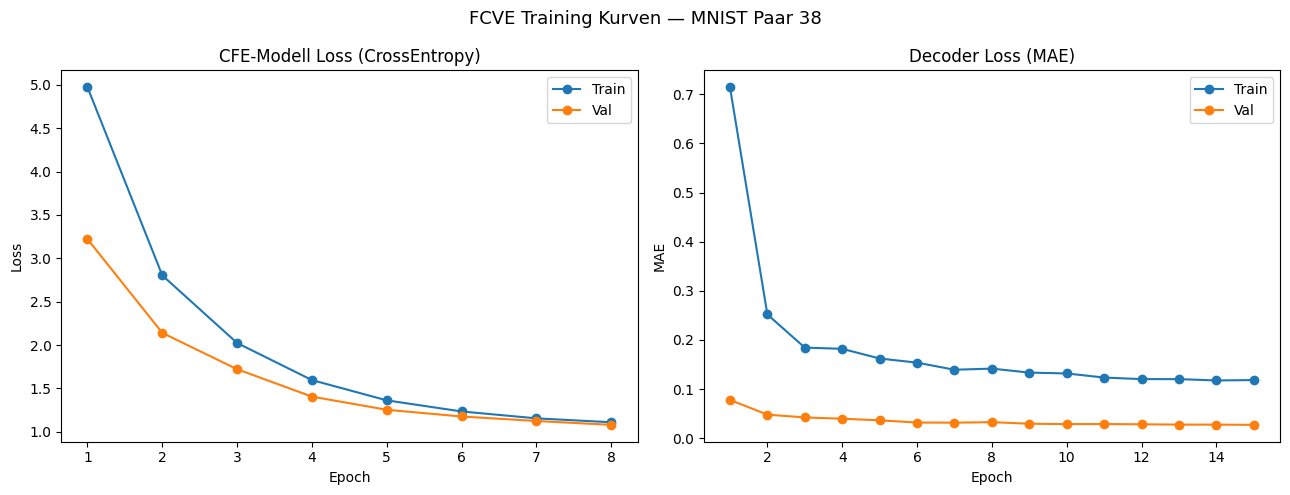

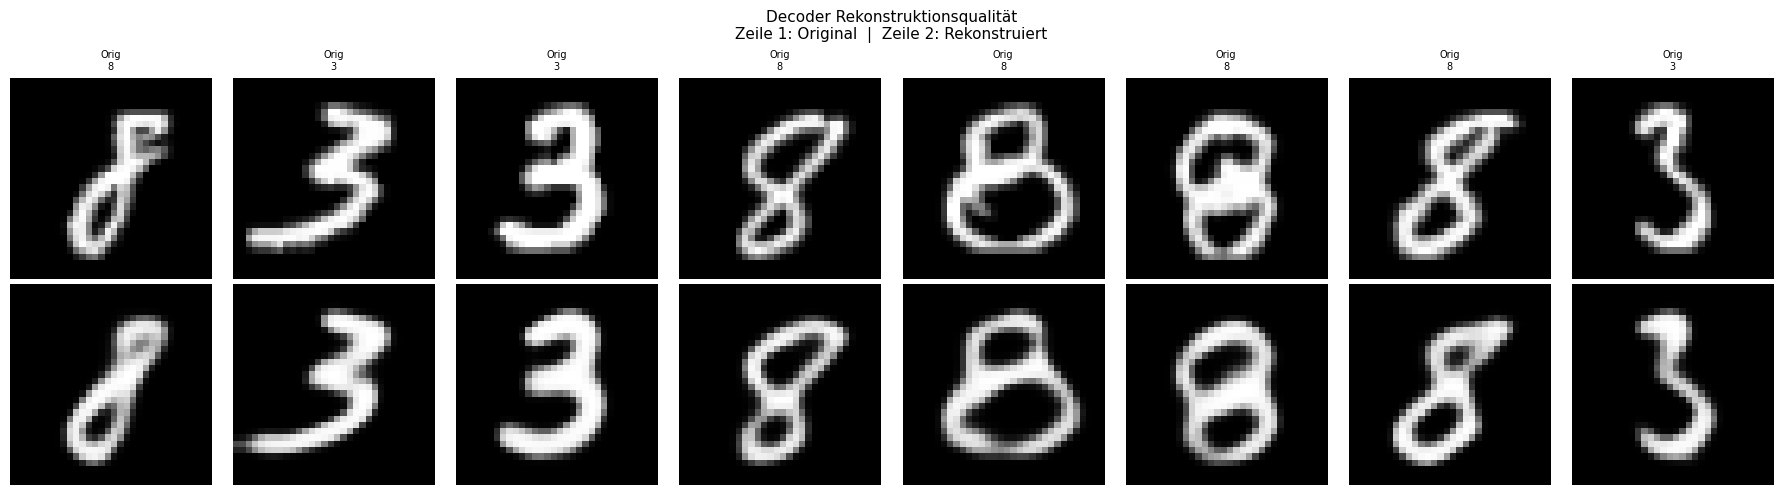

MAE auf Stichprobe: 0.0322  (niedriger = besser)
Batch-Groesse   : 64
Flip Rate     : 100.00%  (Ziel: >60%)


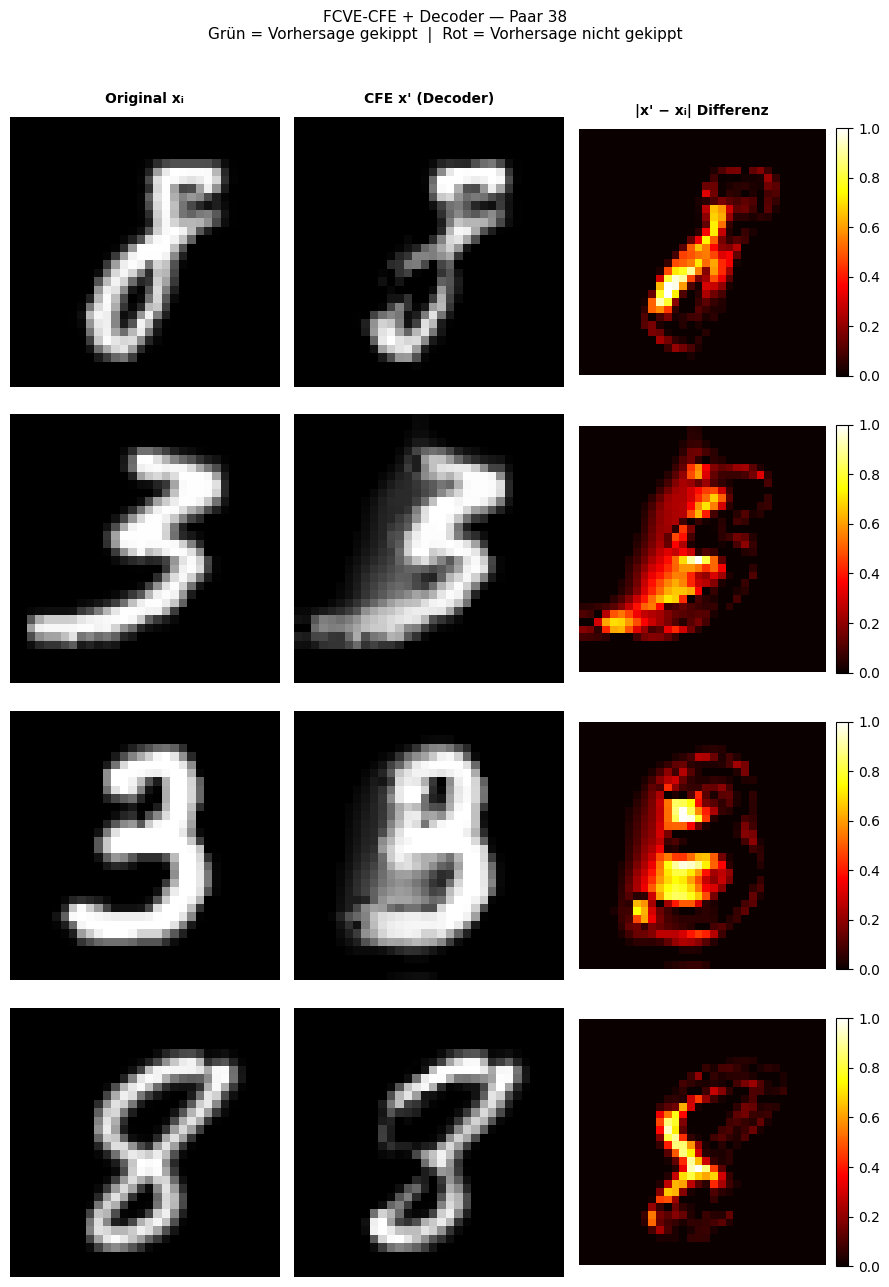

Gespeichert -> /kaggle/working/fcve_38.png


FCVE Evaluation: 100%|██████████| 10/10 [00:00<00:00, 23.86it/s]



Flip Rate: 640/640 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 2/2 [00:00<00:00,  4.71it/s]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


...

Ep 11/15  Train Loss=0.1053  Val MAE (Rekon)=0.0237  Val Flip-Rate (Composite)=0.9881


Ep 12/15  Train Loss=0.1041  Val MAE (Rekon)=0.0229  Val Flip-Rate (Composite)=0.9924


Ep 13/15  Train Loss=0.1035  Val MAE (Rekon)=0.0223  Val Flip-Rate (Composite)=0.9941


Ep 14/15  Train Loss=0.1000  Val MAE (Rekon)=0.0222  Val Flip-Rate (Composite)=0.9915


Ep 15/15  Train Loss=0.1008  Val MAE (Rekon)=0.0222  Val Flip-Rate (Composite)=0.9941
Bester Checkpoint: Val Flip-Rate=0.9966 (wiederhergestellt)

Decoder gespeichert -> /kaggle/working//fcve_decoder_49.pth OK


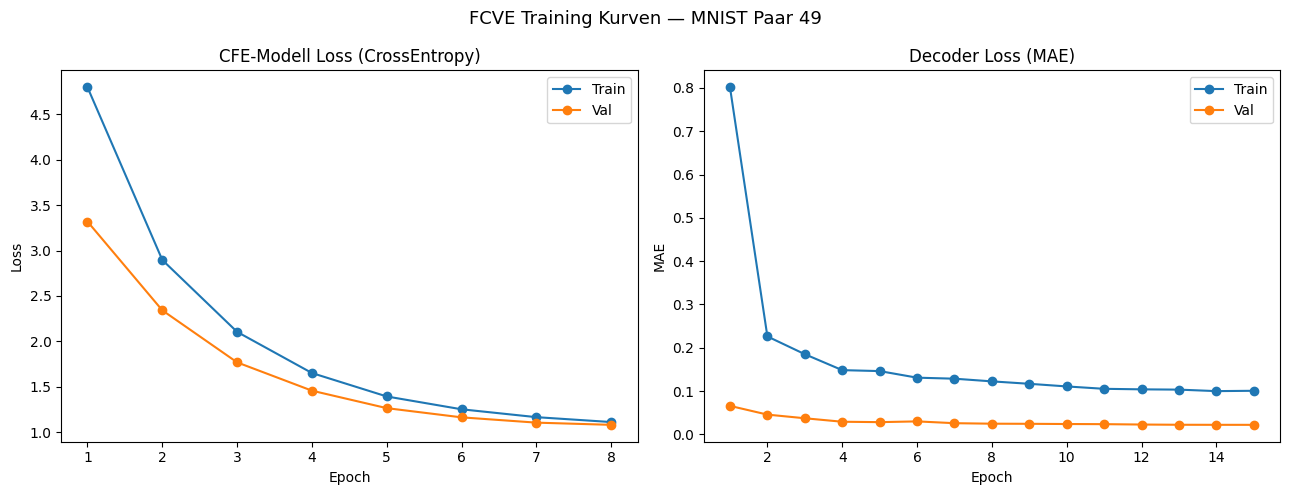

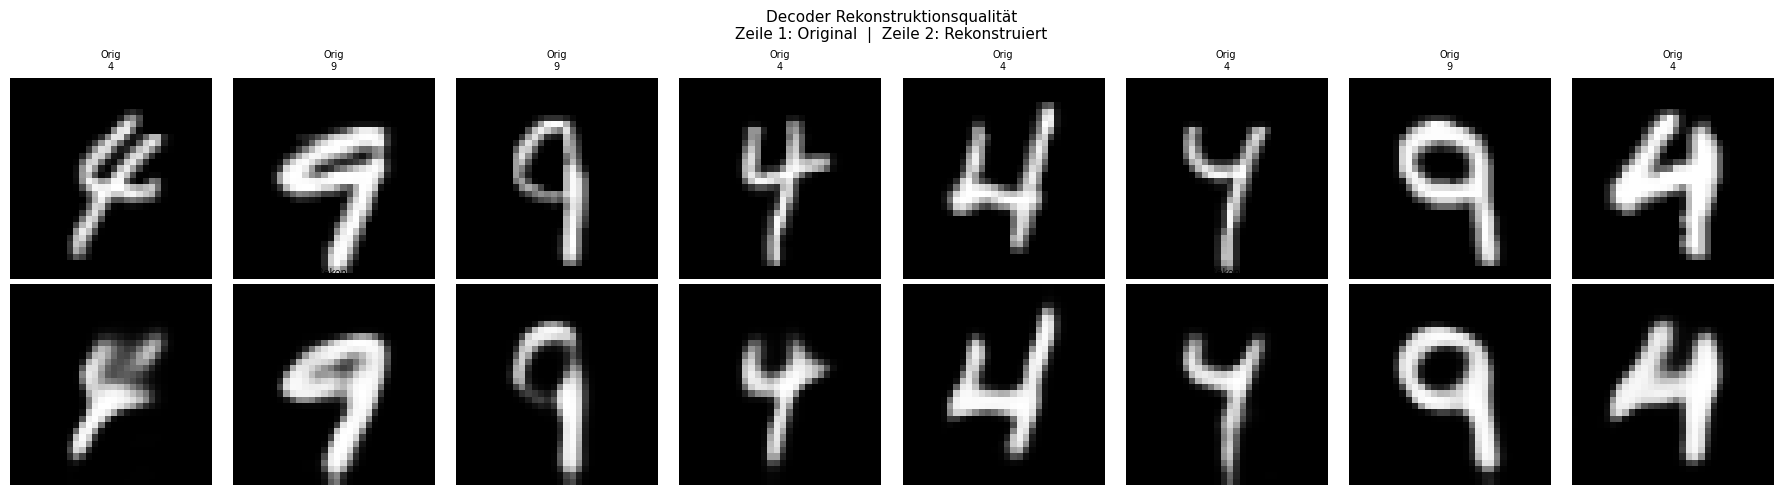

MAE auf Stichprobe: 0.0291  (niedriger = besser)
Batch-Groesse   : 64
Flip Rate     : 100.00%  (Ziel: >60%)


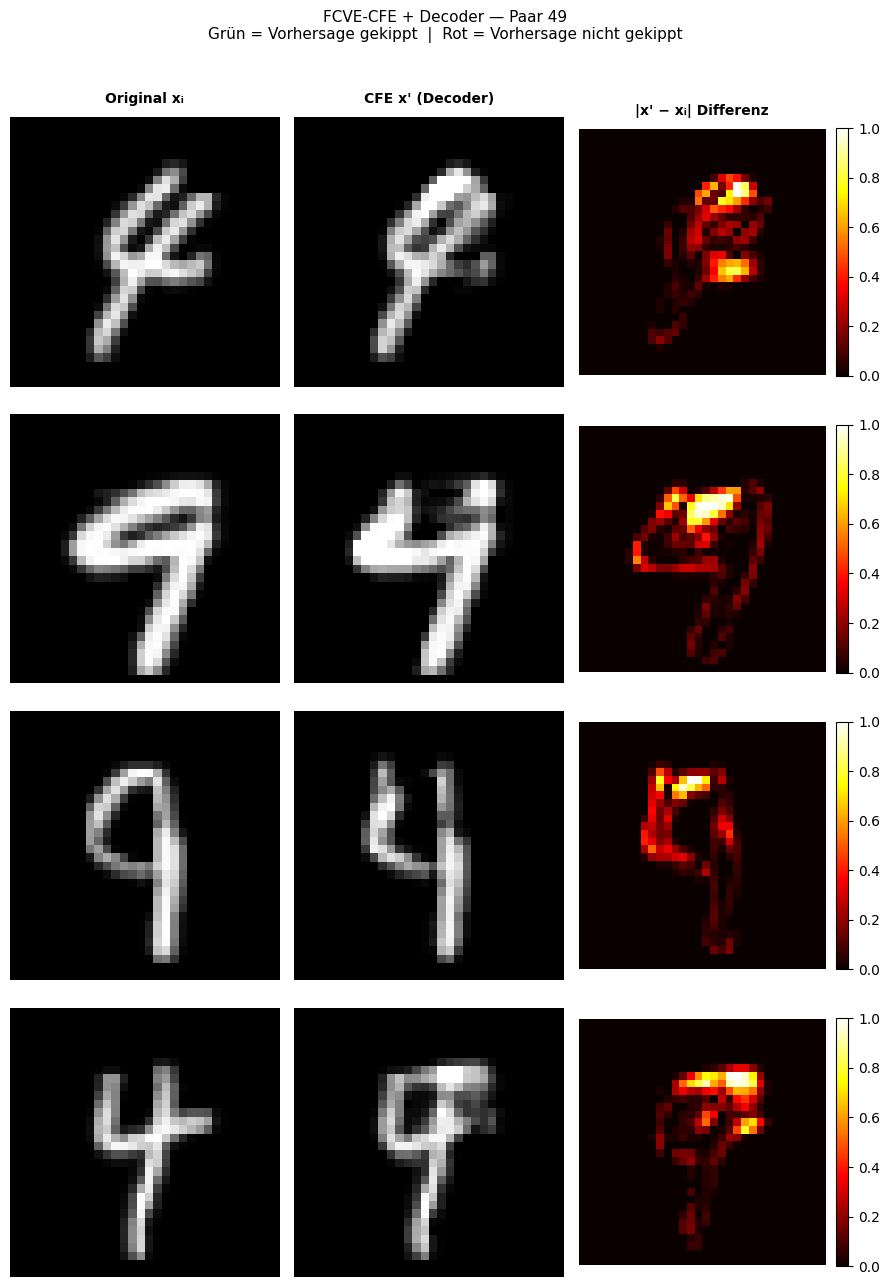

Gespeichert -> /kaggle/working/fcve_49.png


FCVE Evaluation: 100%|██████████| 10/10 [00:00<00:00, 22.69it/s]



Flip Rate: 640/640 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 2/2 [00:00<00:00,  8.05it/s]


Berechne Coverage (5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — FCVE-CFE MNIST Paar 49

-- Proximity --
  L1-Distanz:           0.0389  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.2094  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0594  (niedriger = besser)

-- Plausibilitaet --
  FID:                  84.24   (niedriger = besser)

-- Funktionalitaet --
  Validity:             100.00%  (hoeher = besser)
  Denoised Validity:    100.00%  (hoeher = besser, sigma=1.0)
  Delta Validity:       0.00%  (niedriger = besser = weniger adversarial)
  Coverage:             100.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.000s / CF  (niedriger = besser)

Ergebnis fuer FCVE / Paar 49 in /kaggle/working/metrics_summary.csv gespeichert.

######################################################################
# FCVE — Ziffernpaar 56 (5, 6)
######################################################################
Paar: 56 (5, 6)
Klassifikator-Checkp

...

Ep 11/15  Train Loss=0.1326  Val MAE (Rekon)=0.0264  Val Flip-Rate (Composite)=0.9841


Ep 12/15  Train Loss=0.1248  Val MAE (Rekon)=0.0260  Val Flip-Rate (Composite)=0.9929


Ep 13/15  Train Loss=0.1193  Val MAE (Rekon)=0.0256  Val Flip-Rate (Composite)=0.9894


Ep 14/15  Train Loss=0.1188  Val MAE (Rekon)=0.0256  Val Flip-Rate (Composite)=0.9929


Ep 15/15  Train Loss=0.1169  Val MAE (Rekon)=0.0252  Val Flip-Rate (Composite)=0.9921
Bester Checkpoint: Val Flip-Rate=0.9974 (wiederhergestellt)

Decoder gespeichert -> /kaggle/working//fcve_decoder_56.pth OK


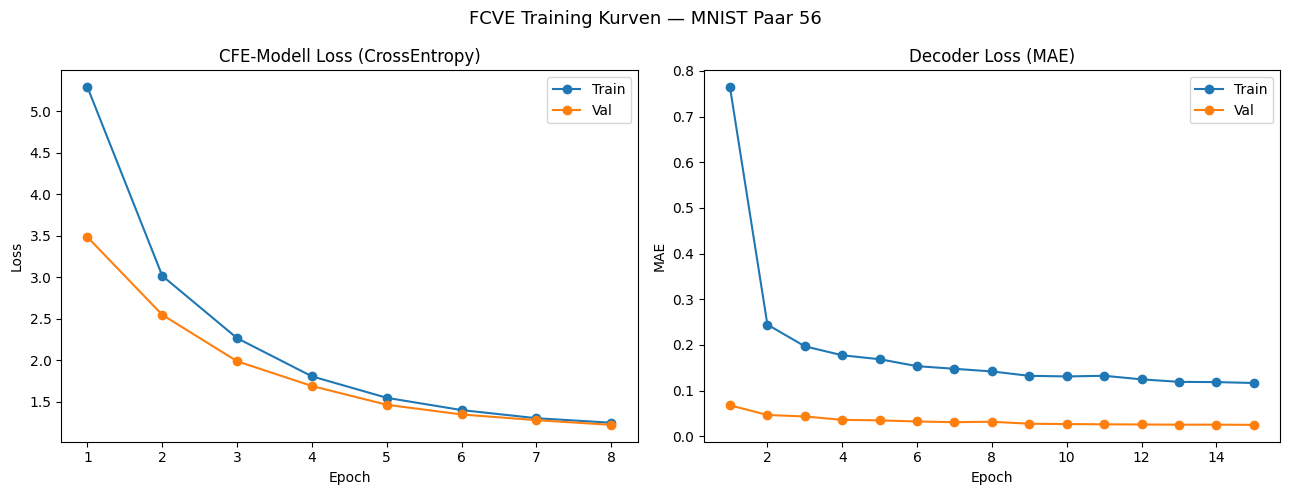

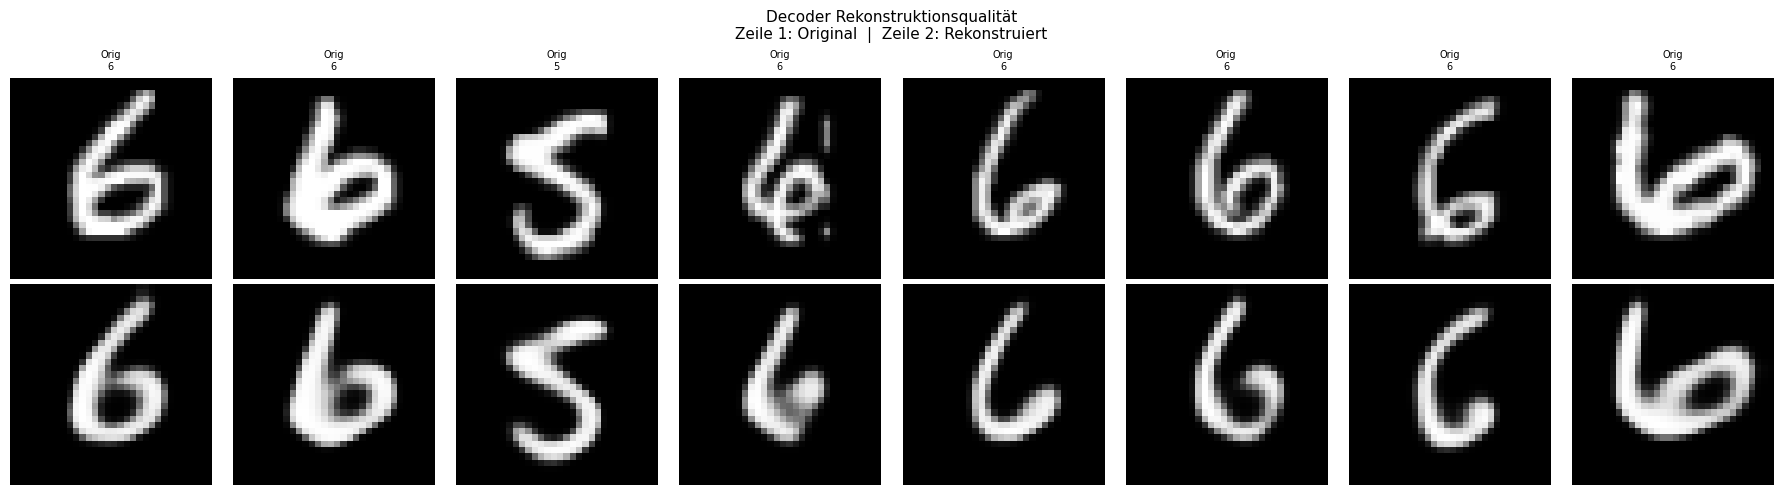

MAE auf Stichprobe: 0.0350  (niedriger = besser)
Batch-Groesse   : 64
Flip Rate     : 100.00%  (Ziel: >60%)


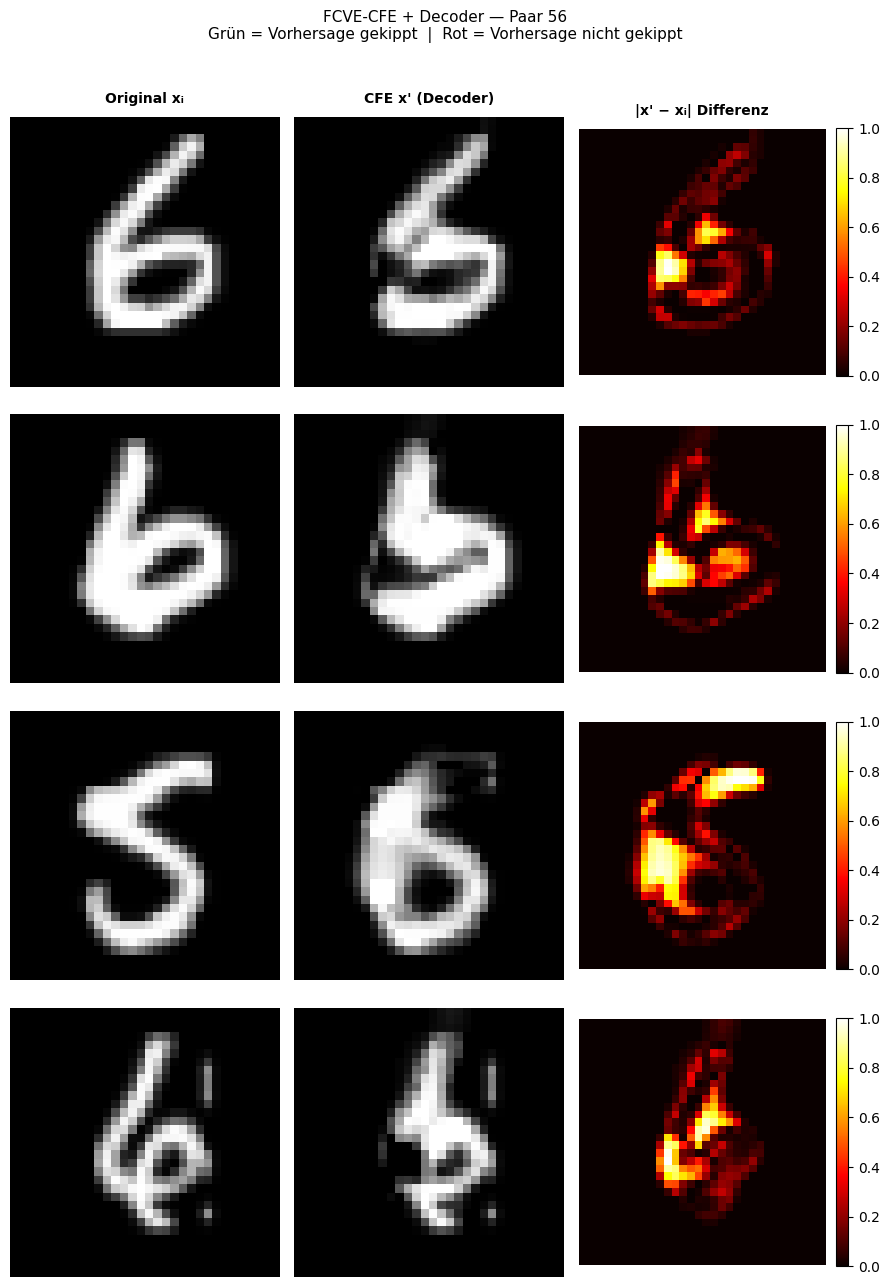

Gespeichert -> /kaggle/working/fcve_56.png


FCVE Evaluation: 100%|██████████| 10/10 [00:00<00:00, 22.51it/s]



Flip Rate: 640/640 = 100.00%
Fester Eval-Satz: 80 Bilder (Seed 42)
Berechne Metriken ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 2/2 [00:00<00:00,  7.96it/s]


Berechne Coverage (5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — FCVE-CFE MNIST Paar 56

-- Proximity --
  L1-Distanz:           0.0609  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.2639  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0532  (niedriger = besser)

-- Plausibilitaet --
  FID:                  117.73   (niedriger = besser)

-- Funktionalitaet --
  Validity:             100.00%  (hoeher = besser)
  Denoised Validity:    96.25%  (hoeher = besser, sigma=1.0)
  Delta Validity:       3.75%  (niedriger = besser = weniger adversarial)
  Coverage:             100.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.000s / CF  (niedriger = besser)

Ergebnis fuer FCVE / Paar 56 in /kaggle/working/metrics_summary.csv gespeichert.

Alle 3 Ziffernpaare durchgelaufen.


In [10]:
all_results = []
for _pk in TASK_PAIRS:
    all_results.append(run_fcve_pipeline(_pk))

print('\n' + '=' * 70)
print('Alle 3 Ziffernpaare durchgelaufen.')
print('=' * 70)


## 13. Mittelwert ueber alle 3 Ziffernpaare

In [11]:
import pandas as pd

numeric_cols = ['l1', 'sparsity_rate', 'lpips', 'fid', 'validity', 'denoised_validity',
                'delta_validity', 'coverage_mean', 'coverage_std', 'efficiency_sec']

df = pd.DataFrame(all_results)
mean_row = {'method': METHOD, 'pair_key': 'MEAN', 'digit_pair': 'Mittelwert ueber alle 3 Paare'}
for col in numeric_cols:
    vals = pd.to_numeric(df[col], errors='coerce')
    mean_row[col] = round(float(vals.mean()), 4)
mean_row['n_eval'] = N_EVAL_IMAGES
mean_row['eval_seed'] = EVAL_SEED

# Mittelwert-Zeile ebenfalls in metrics_summary.csv anhaengen (ersetzt alte MEAN-Zeile)
SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary.csv')
existing_rows = []
if os.path.exists(SUMMARY_PATH):
    with open(SUMMARY_PATH, newline='') as f:
        existing_rows = list(__import__('csv').DictReader(f))
existing_rows = [r for r in existing_rows if not (r['method'] == METHOD and r['pair_key'] == 'MEAN')]
existing_rows.append({k: str(v) for k, v in mean_row.items()})
fieldnames = list(row_keys := list(existing_rows[0].keys())) if existing_rows else list(mean_row.keys())
with open(SUMMARY_PATH, 'w', newline='') as f:
    writer = __import__('csv').DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

print('=' * 70)
print(f'METRIK-ERGEBNISSE — FCVE MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N={len(all_results)})')
print('=' * 70)
print(f"\n-- Proximity --")
print(f"  L1-Distanz:           {mean_row['l1']:.4f}")
print(f"\n-- Interpretierbarkeit --")
print(f"  Sparsity Rate:        {mean_row['sparsity_rate']:.4f}")
print(f"  LPIPS (SqueezeNet):   {mean_row['lpips']:.4f}")
print(f"\n-- Plausibilitaet --")
print(f"  FID:                  {mean_row['fid']:.2f}")
print(f"\n-- Funktionalitaet --")
print(f"  Validity:             {mean_row['validity']:.2%}")
print(f"  Denoised Validity:    {mean_row['denoised_validity']:.2%}")
print(f"  Delta Validity:       {mean_row['delta_validity']:.2%}")
print(f"  Coverage:             {mean_row['coverage_mean']:.2%} +/- {mean_row['coverage_std']:.2%}")
print(f"  Efficiency:           {mean_row['efficiency_sec']:.3f}s / CF")
print('=' * 70)

df_display = pd.DataFrame(all_results + [mean_row])
df_display


METRIK-ERGEBNISSE — FCVE MNIST — MITTELWERT ueber alle 3 Ziffernpaare (N=3)

-- Proximity --
  L1-Distanz:           0.0491

-- Interpretierbarkeit --
  Sparsity Rate:        0.2431
  LPIPS (SqueezeNet):   0.0491

-- Plausibilitaet --
  FID:                  107.94

-- Funktionalitaet --
  Validity:             99.58%
  Denoised Validity:    88.33%
  Delta Validity:       11.25%
  Coverage:             100.00% +/- 0.00%
  Efficiency:           0.001s / CF


,method,pair_key,digit_pair,l1,sparsity_rate,lpips,fid,validity,denoised_validity,delta_validity,coverage_mean,coverage_std,efficiency_sec,n_eval,eval_seed
0,FCVE,38,3-8,0.0474,0.2561,0.0348,121.8600,0.9875,0.6875,0.3000,1.0,0.0,0.0007,80,42
1,FCVE,49,4-9,0.0389,0.2094,0.0594,84.2400,1.0000,1.0000,0.0000,1.0,0.0,0.0004,80,42
2,FCVE,56,5-6,0.0609,0.2639,0.0532,117.7300,1.0000,0.9625,0.0375,1.0,0.0,0.0004,80,42
3,FCVE,MEAN,Mittelwert ueber alle 3 Paare,0.0491,0.2431,0.0491,107.9433,0.9958,0.8833,0.1125,1.0,0.0,0.0005,80,42
